#  Notebook 2 · Xây dựng & Huấn luyện Mô hình — MobileNetV2 

**Mục tiêu:** Xây dựng và huấn luyện mô hình phân loại người hút thuốc bằng **Transfer Learning** kết hợp cơ chế **Attention (CBAM)** đa tỉ lệ (multi-scale).

---

### Chiến lược huấn luyện 2 giai đoạn

| Giai đoạn | Backbone | Learning Rate | Mục đích |
|:---------:|:--------:|:------------:|----------|
| **Phase 1** – Warm-up |  Frozen | `1e-3` | Huấn luyện classifier head hội tụ nhanh |
| **Phase 2** – Fine-tune |  Unfrozen (top 54 layers) | `1e-5` | Tinh chỉnh backbone để tối đa hoá accuracy |


## Cấu hình & Chuẩn bị Môi trường

Thiết lập đường dẫn dữ liệu, thư mục lưu model và các siêu tham số cốt lõi.

| Siêu tham số | Giá trị |
|---|:---:|
| `BATCH_SIZE` | 32 |
| `IMG_SIZE` | 224 × 224 |
| `Classes` | `not_smoking`, `smoking` |


In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

CURRENT_DIR = os.getcwd()
if os.path.basename(CURRENT_DIR) == 'notebooks':
    BASE_DIR = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = os.path.join(BASE_DIR, 'dataset', 'processed_dataset')
MODEL_SAVE_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
CLASSES = ['not_smoking', 'smoking'] 

print(f"Đang tải dữ liệu từ: {DATA_DIR}")




Đang tải dữ liệu từ: d:\Dev\smoker_detection\dataset\processed_dataset


## 1 · Data Pipeline — Phân chia Tập & Augmentation

**Phân chia dữ liệu (Stratified Split):** 70% train / 15% val / 15% test.

**Augmentation (chỉ áp dụng cho tập train):**

| Kỹ thuật | Tham số | Mục đích |
|----------|:-------:|----------|
| `rotation_range` | ±30° | Bất biến với góc xoay |
| `zoom_range` | ±15% | Bất biến với tỉ lệ thu phóng nhỏ |
| `width/height_shift` | ±10% | Bất biến với dịch chuyển |
| `horizontal_flip` | True | Bất biến trái–phải |
| `brightness_range` | [0.8, 1.2] | Bất biến với điều kiện ánh sáng |


In [2]:
filepaths = []
labels = []
for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.exists(cls_path):
        files = [os.path.join(cls_path, f) for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        filepaths.extend(files)
        labels.extend([cls] * len(files))

df = pd.DataFrame({'Filepath': filepaths, 'Label': labels})
print(f"Tổng cộng nạp được {len(df)} ảnh.")

# Chia Train / Val / Test (70% - 15% - 15%)
train_df, Temp_df = train_test_split(df, test_size=0.3, stratify=df['Label'], random_state=42)
test_df, val_df = train_test_split(Temp_df, test_size=0.5, stratify=Temp_df['Label'], random_state=42)

# Lưu Test set
test_df.to_csv(os.path.join(DATA_DIR, 'test_dataset.csv'), index=False)

# Tính Class Weights (Trọng số chống mất cân bằng lớp)
labels_train = train_df['Label'].map({'not_smoking': 0, 'smoking': 1}).values
weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels_train), y=labels_train)
class_weights = dict(enumerate(weights))
print(f"Class Weights: {class_weights}")

# KHỞI TẠO DATA GENERATOR 

train_gen = ImageDataGenerator(
    rotation_range=30, 
    zoom_range=0.15, 
    width_shift_range=0.1, 
    height_shift_range=0.1,
    horizontal_flip=True, 
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)
val_gen = ImageDataGenerator()

train_images = train_gen.flow_from_dataframe(
    train_df, x_col='Filepath', y_col='Label', target_size=IMG_SIZE,
    color_mode='rgb', class_mode='categorical', batch_size=BATCH_SIZE, shuffle=True
)

val_images = val_gen.flow_from_dataframe(
    val_df, x_col='Filepath', y_col='Label', target_size=IMG_SIZE,
    color_mode='rgb', class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False
)

Tổng cộng nạp được 3076 ảnh.
Class Weights: {0: 1.0252380952380953, 1: 0.9759746146872167}
Found 2153 validated image filenames belonging to 2 classes.
Found 462 validated image filenames belonging to 2 classes.


## 2 · Kiến trúc Mô hình — MobileNetV2 + CBAM Multi-Scale

### Backbone: MobileNetV2 (pre-trained trên ImageNet)

MobileNetV2 sử dụng **depthwise separable convolutions** và **inverted residuals** cho đặc trưng mạnh mẽ với chi phí tính toán thấp.

---

### Cơ chế Chú ý: CBAM _(Convolutional Block Attention Module)_

CBAM kết hợp hai loại attention:

1. **Channel Attention** — MLP với GlobalAvgPool + GlobalMaxPool → Sigmoid → trọng số kênh
2. **Spatial Attention** — Mean + Max theo trục kênh → Conv 7×7 → Sigmoid → trọng số vị trí

---

### Thiết kế Multi-Scale 2 Nhánh

| Nhánh | Feature Map | Đối tượng phát hiện |
|:-----:|:-----------:|---------------------|
| **Shallow** (`block_6_expand_relu`) | 28 × 28 × 192 → Conv(256) | Điếu thuốc, móng tay, chi tiết nhỏ |
| **Deep** (MobileNetV2 output) | 7 × 7 × 1280 | Cột khói, tư thế toàn thân |

Sau khi qua CBAM → `GlobalAveragePooling2D` → `Concatenate(1536)` → `Dropout(0.5)` → `Dense(2, softmax)`.

> **Tổng params:** ~3.15M &nbsp;|&nbsp; **Trainable (Phase 1):** ~0.89M


In [3]:

#  ĐỊNH NGHĨA KIẾN TRÚC MẠNG (CBAM + MULTI-SCALE)

def cbam_block(cbam_feature, ratio=8):
    """Mô-đun tập trung (Attention) giúp mô hình khoanh vùng điếu thuốc/khói"""
    cbam_feature_channels = cbam_feature.shape[-1]
    
    # Channel attention
    avg_pool = layers.GlobalAveragePooling2D()(cbam_feature)
    avg_pool = layers.Dense(cbam_feature_channels // ratio, activation='relu', kernel_initializer='he_normal')(avg_pool)
    avg_pool = layers.Dense(cbam_feature_channels, activation='linear', kernel_initializer='he_normal')(avg_pool)
    
    max_pool = layers.GlobalMaxPooling2D()(cbam_feature)
    max_pool = layers.Dense(cbam_feature_channels // ratio, activation='relu', kernel_initializer='he_normal')(max_pool)
    max_pool = layers.Dense(cbam_feature_channels, activation='linear', kernel_initializer='he_normal')(max_pool)
    
    cbam_feature_add = layers.Add()([avg_pool, max_pool])
    cbam_feature_act = layers.Activation('sigmoid')(cbam_feature_add)
    cbam_feature_act = layers.Reshape((1, 1, cbam_feature_channels))(cbam_feature_act)
    channel_attention = layers.Multiply()([cbam_feature, cbam_feature_act])
    
    # Spatial attention
    avg_pool_spatial = tf.reduce_mean(channel_attention, axis=-1, keepdims=True)
    max_pool_spatial = tf.reduce_max(channel_attention, axis=-1, keepdims=True)
    spatial_concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(spatial_concat)
    
    return layers.Multiply()([channel_attention, spatial_attention])

def build_model():
    # 1. Khởi tạo Backbone
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False # Đóng băng toàn bộ trong Giai đoạn 1

    # 2. Tạo mô hình trích xuất trung gian (Bộ não soi ảnh)
    shallow_layer_name = 'block_6_expand_relu'
    feature_extractor = Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(shallow_layer_name).output, base_model.output]
    )

    # 3. Định nghĩa Input và Tiền xử lý
    inputs = layers.Input(shape=(224,224,3))
    x = layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(inputs)
    
    # 4. Trích xuất đặc trưng Nông & Sâu
    shallow_features, deep_features = feature_extractor(x, training=False)
    
    # --- NHÁNH 1: Tầng Nông (điếu thuốc, móng tay) ---
    x_shallow = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(shallow_features)
    x_shallow = cbam_block(x_shallow, ratio=8)
    pool_cigarette = layers.GlobalAveragePooling2D(name='pool_cigarette')(x_shallow)
    
    # --- NHÁNH 2: Tầng Sâu (mảng khói, tư thế người) ---
    x_deep = cbam_block(deep_features, ratio=16)
    pool_smoke = layers.GlobalAveragePooling2D(name='pool_smoke')(x_deep)
    
    # 5. Gộp đặc trưng và Phân loại
    x_concat = layers.Concatenate()([pool_cigarette, pool_smoke])
    x = layers.Dropout(0.5)(x_concat)
    outputs = layers.Dense(2, activation='softmax')(x)

    model = Model(inputs, outputs)
    
    return model, base_model

model, base_model = build_model()
model.summary()



Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 lambda (Lambda)             (None, 224, 224, 3)          0         ['input_2[0][0]']             
                                                                                                  
 model (Functional)          [(None, 28, 28, 192),        2257984   ['lambda[0][0]']              
                              (None, 7, 7, 1280)]                                                 
                                                                                                  
 conv2d (Conv2D)             (None, 28, 28, 256)          442624    ['model[0][0]']       

## 3 · Huấn luyện

### Giai đoạn 1 — Warm-up (HEAD ONLY)

Backbone bị **đóng băng** hoàn toàn (`base_model.trainable = False`).  
Chỉ huấn luyện phần classifier head để tránh phá hủy trọng số ImageNet.

**Callbacks được sử dụng:**

| Callback | Monitor | Hành động |
|----------|---------|----------|
| `ModelCheckpoint` | `val_accuracy ↑` | Lưu best model |
| `EarlyStopping` | `val_accuracy` (patience=5) | Dừng sớm khi không cải thiện |
| `ReduceLROnPlateau` | `val_loss` (patience=3, ×0.2) | Giảm learning rate khi plateau |


In [4]:
model_save_path = os.path.join(MODEL_SAVE_DIR, 'smoker_detector_best.keras')

callbacks = [
    ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, mode='max'),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

print("\n BẮT ĐẦU GIAI ĐOẠN 1: HUẤN LUYỆN PHẦN ĐẦU (HEAD)...")
history_stage_1 = model.fit(
    train_images,
    validation_data=val_images,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)


 BẮT ĐẦU GIAI ĐOẠN 1: HUẤN LUYỆN PHẦN ĐẦU (HEAD)...
Epoch 1/15


68/68 [==============================] - 138s 2s/step - loss: 0.5935 - accuracy: 0.6860 - val_loss: 0.5150 - val_accuracy: 0.7619 - lr: 0.0010
Epoch 2/15
68/68 [==============================] - 90s 1s/step - loss: 0.5050 - accuracy: 0.7678 - val_loss: 0.5067 - val_accuracy: 0.7662 - lr: 0.0010
Epoch 3/15
68/68 [==============================] - 58s 853ms/step - loss: 0.4944 - accuracy: 0.7603 - val_loss: 0.4950 - val_accuracy: 0.7662 - lr: 0.0010
Epoch 4/15
68/68 [==============================] - 81s 1s/step - loss: 0.4676 - accuracy: 0.7738 - val_loss: 0.5216 - val_accuracy: 0.7511 - lr: 0.0010
Epoch 5/15
68/68 [==============================] - 79s 1s/step - loss: 0.4703 - accuracy: 0.7831 - val_loss: 0.4900 - val_accuracy: 0.7662 - lr: 0.0010
Epoch 6/15
68/68 [==============================] - 85s 1s/step - loss: 0.4447 - accuracy: 0.7980 - val_loss: 0.4791 - val_accuracy: 0.7619 - lr: 0.0010
Epoch 7/15
68/68 [=====

###  Giai đoạn 2 — Fine-tuning (BACKBONE)

Mở khóa **54 lớp cuối** của MobileNetV2 và huấn luyện lại với learning rate rất nhỏ (`1e-5`).  
Chiến lược này giúp backbone thích nghi với đặc trưng domain (phát hiện thuốc lá) mà không phá hủy kiến thức từ ImageNet.

> **Output:** `models/smoker_detector_best.keras` &nbsp;&amp;&nbsp; `models/smoker_detector_final.keras`


In [5]:

print("\n BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING BACKBONE...")

base_model.trainable = True


for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

history_stage_2 = model.fit(
    train_images,
    validation_data=val_images,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)

model.save(os.path.join(MODEL_SAVE_DIR, 'smoker_detector_final.keras'))
print(" Đã huấn luyện xong và lưu mô hình thành công!")


 BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING BACKBONE...
Epoch 1/15
68/68 [==============================] - 107s 1s/step - loss: 0.4230 - accuracy: 0.8031 - val_loss: 0.4801 - val_accuracy: 0.7944 - lr: 1.0000e-05
Epoch 2/15
68/68 [==============================] - 102s 1s/step - loss: 0.3972 - accuracy: 0.8258 - val_loss: 0.4516 - val_accuracy: 0.8095 - lr: 1.0000e-05
Epoch 3/15
68/68 [==============================] - 88s 1s/step - loss: 0.3690 - accuracy: 0.8393 - val_loss: 0.4448 - val_accuracy: 0.8117 - lr: 1.0000e-05
Epoch 4/15
68/68 [==============================] - 93s 1s/step - loss: 0.3634 - accuracy: 0.8388 - val_loss: 0.4490 - val_accuracy: 0.8290 - lr: 1.0000e-05
Epoch 5/15
68/68 [==============================] - 94s 1s/step - loss: 0.3504 - accuracy: 0.8514 - val_loss: 0.4459 - val_accuracy: 0.8333 - lr: 1.0000e-05
Epoch 6/15
68/68 [==============================] - 99s 1s/step - loss: 0.3337 - accuracy: 0.8537 - val_loss: 0.4366 - val_accuracy: 0.8290 - lr: 1.0000e-05
Epoch 7/1

## 4 · Biểu đồ Đánh giá Quá trình Huấn luyện

Vẽ đường cong **Accuracy** và **Loss** xuyên suốt cả 2 giai đoạn.  
Đường đỏ đứt (`--`) đánh dấu thời điểm bắt đầu Fine-tuning.


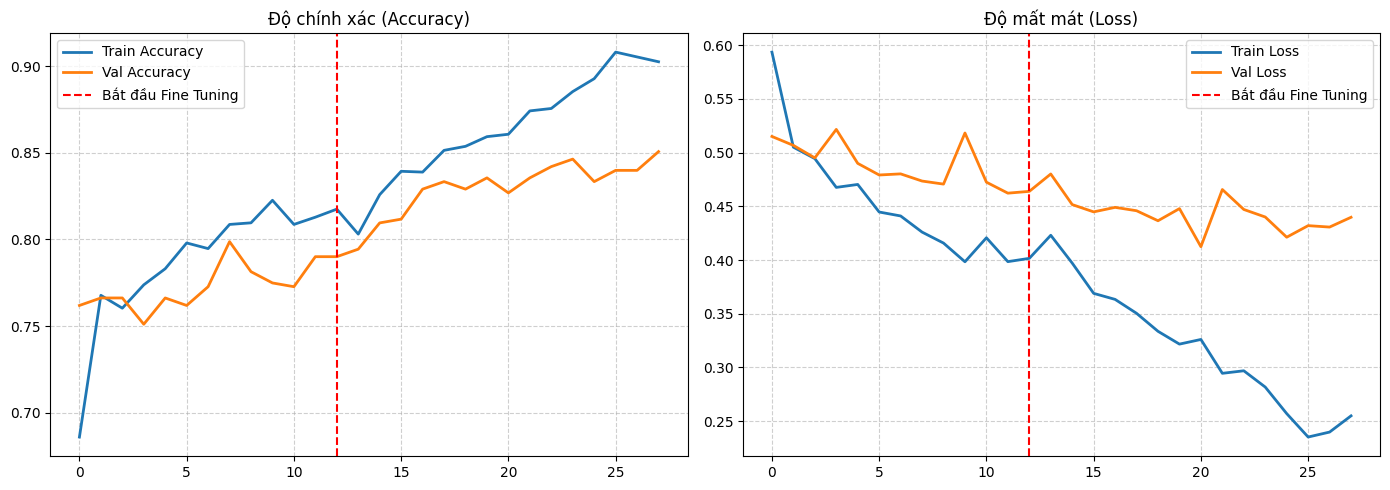

In [6]:

acc = history_stage_1.history['accuracy'] + history_stage_2.history['accuracy']
val_acc = history_stage_1.history['val_accuracy'] + history_stage_2.history['val_accuracy']
loss = history_stage_1.history['loss'] + history_stage_2.history['loss']
val_loss = history_stage_1.history['val_loss'] + history_stage_2.history['val_loss']

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2)
plt.plot(val_acc, label='Val Accuracy', linewidth=2)
plt.axvline(x=len(history_stage_1.history['accuracy'])-1, color='r', linestyle='--', label='Bắt đầu Fine Tuning')
plt.title('Độ chính xác (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Val Loss', linewidth=2)
plt.axvline(x=len(history_stage_1.history['loss'])-1, color='r', linestyle='--', label='Bắt đầu Fine Tuning')
plt.title('Độ mất mát (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()